#  RF-Sentinel — Layer 1: Data Ingestion & Unification
> **Project:** AI-driven RF Component Failure Root Cause Analysis  
> **Layer:** 1 of 6 — Data Ingestion & Unification  
> **Datasets:** CMAPSS · SECOM · AI4I 2020  
> **Output:** 32,198 unified rows · validated RF parameter schema

## What this notebook covers
1. Loading all 3 raw datasets
2. Exploring each dataset structure
3. Feature engineering on CMAPSS
4. Unified RF schema mapping
5. Preprocessed outputs validation

In [ ]:
# Setup — imports and path configuration
import sys
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
sys.path.append("..")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
print(" Imports successful")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")

✅ Imports successful
   pandas  : 2.2.2
   numpy   : 1.26.4


##  CMAPSS Dataset
> **Source:** NASA Turbofan Engine Degradation Simulation  
> **Files:** train_FD001–FD004, test_FD001/FD004, RUL_FD001/FD004  
> **Analogy:** Each engine = one RF component under test  
> **Task:** Predict failure within 30 cycles (binary classification)

In [10]:
from layer1_data_ingestion.loaders import load_cmapss, load_all_cmapss
from layer1_data_ingestion.config import CMAPSS_USEFUL_SENSORS, CMAPSS_SENSOR_LABELS

# Load FD001 — simplest dataset (1 fault, 1 condition)
data_fd001 = load_cmapss("FD001")
train_raw  = data_fd001["train_raw"]

print("=" * 55)
print("CMAPSS FD001 — Dataset Summary")
print("=" * 55)
print(f"  Total rows     : {len(train_raw):,}")
print(f"  Total engines  : {train_raw['unit_id'].nunique()}")
print(f"  Useful sensors : {len(CMAPSS_USEFUL_SENSORS)}")
print(f"  Failure rate   : {train_raw['fail_soon'].mean():.1%}")
print(f"  Avg engine life: {train_raw.groupby('unit_id')['cycle'].max().mean():.0f} cycles")
print()

# Check available columns first
rul_col = "rul" if "rul" in train_raw.columns else "RUL"
print(f"Available columns: {list(train_raw.columns[:10])}...")
print()
print("First 5 rows:")
train_raw[["unit_id","cycle","s2","s3","s4","s9",
           rul_col,"fail_soon"]].head()

2026-05-18 21:42:37.596 | SUCCESS  | layer1_data_ingestion.loaders:load_cmapss:133 - [C-MAPSS | FD001] engines=100 | train_rows=20,631 | fail_rate=15.0% | features=14 | test=yes


CMAPSS FD001 — Dataset Summary
  Total rows     : 20,631
  Total engines  : 100
  Useful sensors : 14
  Failure rate   : 15.0%
  Avg engine life: 206 cycles

Available columns: ['unit_id', 'cycle', 'op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5']...

First 5 rows:


,unit_id,cycle,s2,s3,s4,s9,RUL,fail_soon
0,1,1,641.82,1589.70,1400.60,9046.19,191.0,0
1,1,2,642.15,1591.82,1403.14,9044.07,190.0,0
2,1,3,642.35,1587.99,1404.20,9052.94,189.0,0
3,1,4,642.35,1582.79,1401.87,9049.48,188.0,0
4,1,5,642.37,1582.85,1406.22,9055.15,187.0,0


In [3]:
# All 4 CMAPSS datasets summary
all_cmapss = load_all_cmapss()
print(f"{'Dataset':<10} {'Engines':>8} {'Rows':>10} {'Fail Rate':>10} {'Avg Life':>10}")
print("-" * 50)
for ds_name, ds_data in all_cmapss.items():
    raw = ds_data["train_raw"]
    print(
        f"{ds_name:<10}"
        f"{raw['unit_id'].nunique():>8}"
        f"{len(raw):>10,}"
        f"{raw['fail_soon'].mean():>10.1%}"
        f"{raw.groupby('unit_id')['cycle'].max().mean():>10.0f}"
    )

2026-05-18 21:40:07.935 | SUCCESS  | layer1_data_ingestion.loaders:load_cmapss:133 - [C-MAPSS | FD001] engines=100 | train_rows=20,631 | fail_rate=15.0% | features=14 | test=yes
2026-05-18 21:40:09.482 | SUCCESS  | layer1_data_ingestion.loaders:load_cmapss:133 - [C-MAPSS | FD002] engines=260 | train_rows=53,759 | fail_rate=15.0% | features=14 | test=no
2026-05-18 21:40:10.016 | SUCCESS  | layer1_data_ingestion.loaders:load_cmapss:133 - [C-MAPSS | FD003] engines=100 | train_rows=24,720 | fail_rate=12.5% | features=14 | test=no
2026-05-18 21:40:11.949 | SUCCESS  | layer1_data_ingestion.loaders:load_cmapss:133 - [C-MAPSS | FD004] engines=249 | train_rows=61,249 | fail_rate=12.6% | features=14 | test=yes
2026-05-18 21:40:11.957 | SUCCESS  | layer1_data_ingestion.loaders:load_all_cmapss:174 - [C-MAPSS] All subsets loaded — total train rows: 160,359


Dataset     Engines       Rows  Fail Rate   Avg Life
--------------------------------------------------
FD001          100    20,631     15.0%       206
FD002          260    53,759     15.0%       207
FD003          100    24,720     12.5%       247
FD004          249    61,249     12.6%       246


In [4]:
# Sensor labels — what each sensor measures
print("Useful sensors and their physical meaning:")
print("-" * 50)
for sensor, label in CMAPSS_SENSOR_LABELS.items():
    print(f"  {sensor:<6} → {label}")

Useful sensors and their physical meaning:
--------------------------------------------------
  s2     → Fan inlet temperature (°R)
  s3     → LPC outlet temperature (°R)
  s4     → HPC outlet temperature (°R)
  s7     → HPC outlet pressure (psia)
  s8     → Physical fan speed (rpm)
  s9     → Physical core speed (rpm)
  s11    → HPC outlet static pressure (psia)
  s12    → Ratio of fuel flow to Ps30 (pps/psia)
  s13    → Corrected fan speed (rpm)
  s14    → Corrected core speed (rpm)
  s15    → Bypass ratio
  s17    → Bleed enthalpy
  s20    → HPT coolant bleed (lbm/s)
  s21    → LPT coolant bleed (lbm/s)


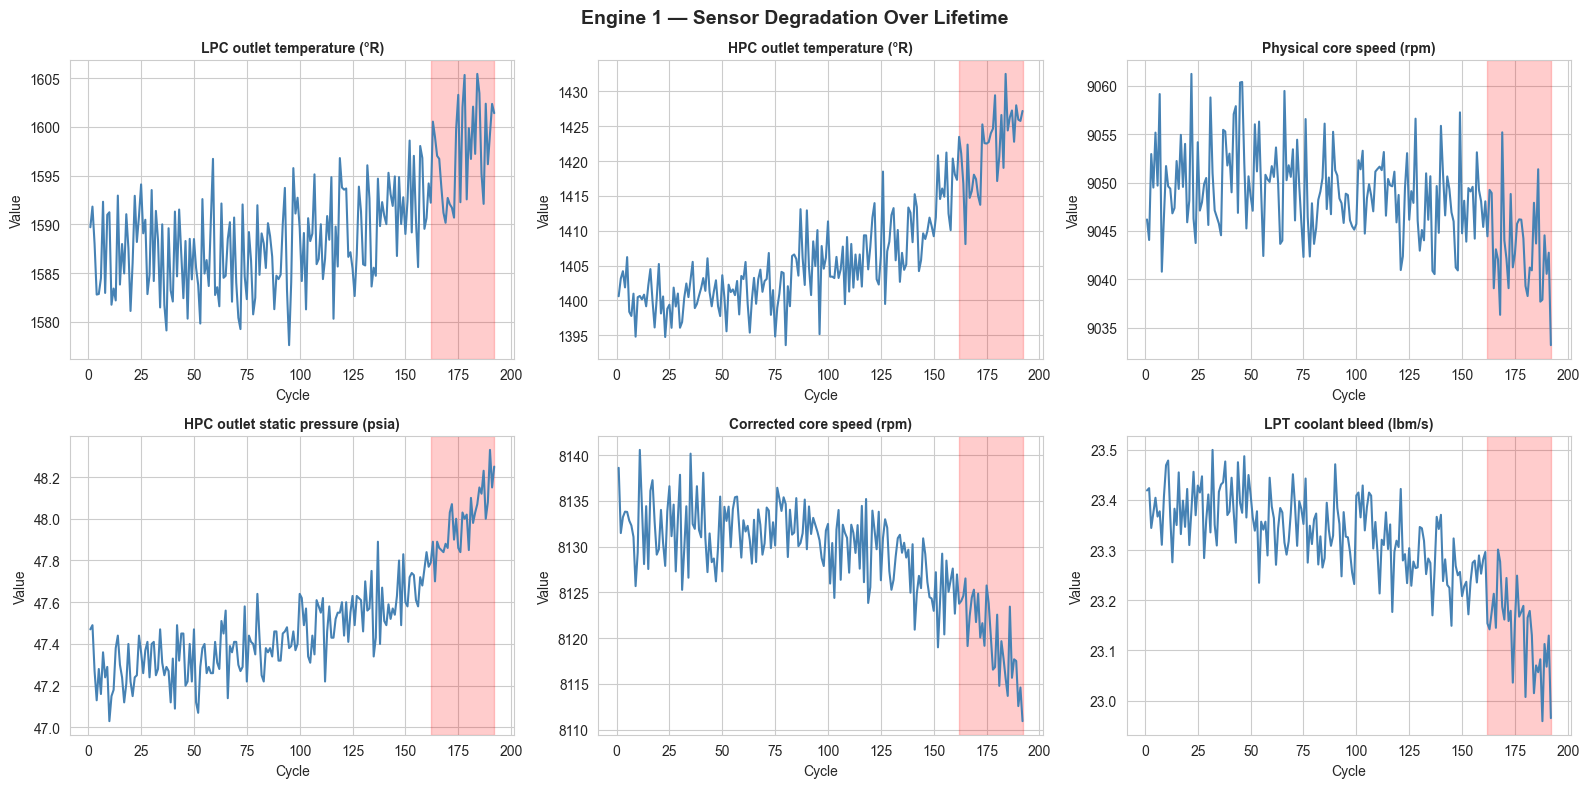

Red zone = last 30 cycles before failure


In [5]:
# Visualise sensor degradation for one engine
engine_1 = train_raw[train_raw["unit_id"] == 1].copy()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

key_sensors = ["s3","s4","s9","s11","s14","s21"]
for i, sensor in enumerate(key_sensors):
    ax = axes[i]
    ax.plot(engine_1["cycle"], engine_1[sensor],
            color="steelblue", linewidth=1.5)
    ax.axvspan(engine_1["cycle"].max()-30,
               engine_1["cycle"].max(),
               alpha=0.2, color="red", label="Failure zone")
    ax.set_title(CMAPSS_SENSOR_LABELS[sensor], fontsize=10, fontweight="bold")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Value")

plt.suptitle("Engine 1 — Sensor Degradation Over Lifetime",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("Red zone = last 30 cycles before failure")

##  SECOM Dataset
> **Source:** UCI ML Repository — Semiconductor Manufacturing  
> **Structure:** 1,567 samples × 562 anonymous sensor readings  
> **Challenge:** Only 6.6% failures + 4.5% missing values  
> **Solution:** SMOTE oversampling + median imputation

2026-05-18 21:40:27.145 | SUCCESS  | layer1_data_ingestion.loaders:load_secom:233 - [SECOM] samples=1,567 | features_kept=562 | features_dropped=28 (>50% missing) | failures=104 / 1567 (6.6%)


SECOM Dataset — Summary
  Samples         : 1,567
  Features        : 562
  Failures        : 104 (6.6%)
  Missing values  : 11,683 (1.3%)
  Dropped cols    : 28 (>50% missing)



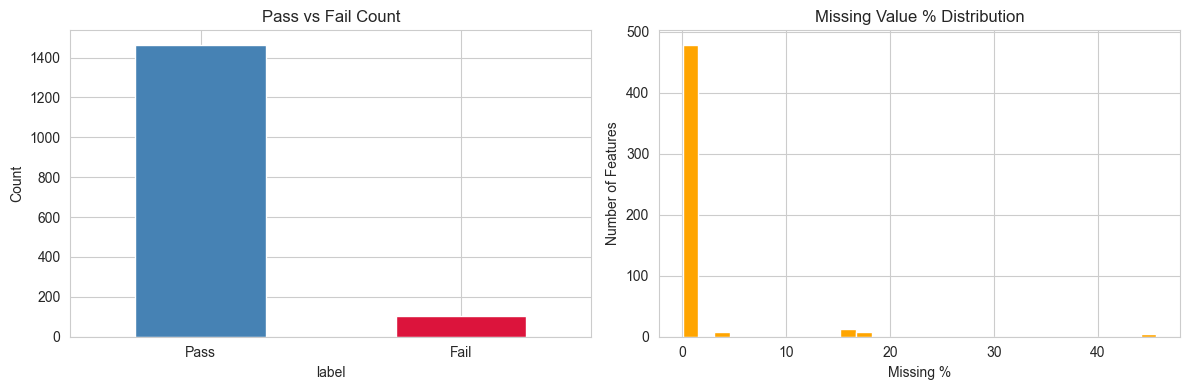

In [6]:
from layer1_data_ingestion.loaders import load_secom

secom = load_secom()
X_secom = secom["X"]
y_secom = secom["y"]

print("=" * 55)
print("SECOM Dataset — Summary")
print("=" * 55)
print(f"  Samples         : {len(X_secom):,}")
print(f"  Features        : {X_secom.shape[1]}")
print(f"  Failures        : {y_secom.sum()} ({y_secom.mean():.1%})")
print(f"  Missing values  : {X_secom.isnull().sum().sum():,} ({X_secom.isnull().mean().mean():.1%})")
print(f"  Dropped cols    : {len(secom['cols_dropped'])} (>50% missing)")
print()

# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_secom.value_counts().plot.bar(
    ax=axes[0], color=["steelblue","crimson"],
    title="Pass vs Fail Count"
)
axes[0].set_xticklabels(["Pass","Fail"], rotation=0)
axes[0].set_ylabel("Count")

missing_per_feature = (X_secom.isnull().sum() / len(X_secom) * 100)
missing_per_feature[missing_per_feature > 0].hist(
    ax=axes[1], bins=30, color="orange", edgecolor="white"
)
axes[1].set_title("Missing Value % Distribution")
axes[1].set_xlabel("Missing %")
axes[1].set_ylabel("Number of Features")

plt.tight_layout()
plt.show()

##  AI4I 2020 Dataset
> **Source:** Kaggle Predictive Maintenance  
> **Structure:** 10,000 samples × 6 process features  
> **Task:** 5-class failure type classification  
> **RF mapping:** TWF→thermal · HDF→heat · PWF→power · OSF→overstrain · RNF→random

In [7]:
from layer1_data_ingestion.loaders import load_ai4i
from layer1_data_ingestion.config import AI4I_FAILURE_COLS

ai4i = load_ai4i()
X_ai4i = ai4i["X"]
y_ai4i = ai4i["y_binary"]

print("=" * 55)
print("AI4I 2020 Dataset — Summary")
print("=" * 55)
print(f"  Samples         : {len(X_ai4i):,}")
print(f"  Features        : {X_ai4i.shape[1]}")
print(f"  Total failures  : {y_ai4i.sum()} ({y_ai4i.mean():.1%})")
print()
print("Failure type breakdown:")
print("-" * 40)
for col in AI4I_FAILURE_COLS:
    count = ai4i["df_raw"][col].sum()
    pct   = count / len(ai4i["df_raw"]) * 100
    print(f"  {col} : {count:>4} samples ({pct:.2f}%)")
print()
print("Feature columns:")
for col in X_ai4i.columns:
    print(f"  {col}")

2026-05-18 21:40:32.453 | SUCCESS  | layer1_data_ingestion.loaders:load_ai4i:313 - [AI4I] samples=10,000 | features=6 | failures=339 (3.39%) | failure_types=6


AI4I 2020 Dataset — Summary
  Samples         : 10,000
  Features        : 6
  Total failures  : 339 (3.4%)

Failure type breakdown:
----------------------------------------
  TWF :   46 samples (0.46%)
  HDF :  115 samples (1.15%)
  PWF :   95 samples (0.95%)
  OSF :   98 samples (0.98%)
  RNF :   19 samples (0.19%)

Feature columns:
  Type_encoded
  Air temperature [K]
  Process temperature [K]
  Rotational speed [rpm]
  Torque [Nm]
  Tool wear [min]


## 4 Feature Engineering — CMAPSS
> Rolling statistics, delta features, EMA, degradation index  
> Transforms raw sensor readings into ML-ready features

In [8]:
from layer1_data_ingestion.feature_engineering import engineer_cmapss_features

# Apply feature engineering to FD001
print("Before feature engineering:")
print(f"  Columns: {train_raw.shape[1]}")

df_engineered, feat_cols = engineer_cmapss_features(train_raw.copy())

print()
print("After feature engineering:")
print(f"  Columns  : {df_engineered.shape[1]}")
print(f"  New feats: {df_engineered.shape[1] - train_raw.shape[1]}")
print()
print("Feature groups added:")
groups = {
    "Rolling (mean/std/min/max)": [c for c in feat_cols if "roll" in c],
    "Delta (1st/2nd diff)"      : [c for c in feat_cols if "delta" in c],
    "EMA"                       : [c for c in feat_cols if "ema" in c],
    "Cycle features"            : [c for c in feat_cols if "cycle" in c],
    "Cross-sensor"              : [c for c in feat_cols if any(
                                    x in c for x in ["ratio","proxy","thermal","coolant"])]
}
for group, cols in groups.items():
    print(f"  {group:<30}: {len(cols)} features")

2026-05-18 21:40:36.337 | INFO     | layer1_data_ingestion.feature_engineering:engineer_cmapss_features:469 - [FE | C-MAPSS] Starting feature engineering — input: 20,631 rows × 28 cols


Before feature engineering:
  Columns: 28


2026-05-18 21:40:39.453 | INFO     | layer1_data_ingestion.feature_engineering:add_rolling_features:113 - [FE] Rolling features added: 56 columns (14 sensors × 4 stats, window=5)
2026-05-18 21:40:40.009 | INFO     | layer1_data_ingestion.feature_engineering:add_delta_features:161 - [FE] Delta features added: 28 columns (14 sensors × 2 orders)
2026-05-18 21:40:40.319 | INFO     | layer1_data_ingestion.feature_engineering:add_exponential_moving_average:209 - [FE] EMA features added: 14 columns (14 sensors, span=10)
2026-05-18 21:40:40.435 | INFO     | layer1_data_ingestion.feature_engineering:add_cycle_features:247 - [FE] Cycle features added: cycle_pct, cycles_remaining_est, cycle_log
2026-05-18 21:40:40.658 | INFO     | layer1_data_ingestion.feature_engineering:add_degradation_index:308 - [FE] Degradation index added (mean=0.4594, sensors=14)
2026-05-18 21:40:40.737 | INFO     | layer1_data_ingestion.feature_engineering:add_cross_sensor_features:355 - [FE] Cross-sensor features added: 


After feature engineering:
  Columns  : 136
  New feats: 108

Feature groups added:
  Rolling (mean/std/min/max)    : 56 features
  Delta (1st/2nd diff)          : 28 features
  EMA                           : 15 features
  Cycle features                : 3 features
  Cross-sensor                  : 5 features


## 5️ Unified RF Schema
> All 3 datasets mapped to 8 unified RF parameters  
> Enables consistent downstream modeling and comparison

In [9]:
import pandas as pd
from layer1_data_ingestion.config import UNIFIED_DATASET

# Load the unified dataset
unified = pd.read_parquet(UNIFIED_DATASET)

print("=" * 55)
print("Unified RF-Sentinel Dataset")
print("=" * 55)
print(f"  Shape          : {unified.shape}")
print(f"  Overall fail % : {unified['failure_label'].mean():.1%}")
print()
print("Rows per source:")
print(unified["dataset_source"].value_counts().to_string())
print()
print("Failure type distribution:")
print(unified["failure_type"].value_counts().to_string())
print()

# RF parameter mapping table
mapping = {
    "rf_param_1": ("S21 / gain proxy",    "s3 (HPC temp)",      "Air temperature"),
    "rf_param_2": ("Noise figure proxy",  "s4 (LPT temp)",      "Process temp"),
    "rf_param_3": ("P1dB / power proxy",  "s9 (core speed)",    "Rotational speed"),
    "rf_param_4": ("IP3 / linearity",     "s11 (HPC pressure)", "Torque"),
    "rf_param_5": ("Temperature",         "s2 (LPC temp)",      "Air temperature"),
    "rf_param_6": ("Frequency proxy",     "s14 (core speed)",   "Rotational speed"),
    "rf_param_7": ("Pressure / bias",     "s7 (HPC pressure)",  "Tool wear"),
    "rf_param_8": ("Secondary param",     "s21 (coolant)",      "Type encoded"),
}
print("RF Parameter Mapping:")
print(f"{'Param':<12} {'RF Meaning':<22} {'CMAPSS':<22} {'AI4I'}")
print("-" * 75)
for param, (rf, cmapss, ai4i_col) in mapping.items():
    print(f"{param:<12} {rf:<22} {cmapss:<22} {ai4i_col}")

Unified RF-Sentinel Dataset
  Shape          : (32198, 15)
  Overall fail % : 11.0%

Rows per source:
dataset_source
cmapss_FD001    20631
ai4i            10000
secom            1567

Failure type distribution:
failure_type
pass                        28646
sensor_degradation           3100
heat_dissipation_failure      115
manufacturing_defect          104
power_failure                  91
overstrain_failure             78
thermal_wear_failure           46
random_failure                 18

RF Parameter Mapping:
Param        RF Meaning             CMAPSS                 AI4I
---------------------------------------------------------------------------
rf_param_1   S21 / gain proxy       s3 (HPC temp)          Air temperature
rf_param_2   Noise figure proxy     s4 (LPT temp)          Process temp
rf_param_3   P1dB / power proxy     s9 (core speed)        Rotational speed
rf_param_4   IP3 / linearity        s11 (HPC pressure)     Torque
rf_param_5   Temperature            s2 (LPC temp)   

##  Layer 1 Summary

| Item | Value |
|------|-------|
| Datasets loaded | 3 (CMAPSS + SECOM + AI4I) |
| Total raw rows | 160,359 + 1,567 + 10,000 |
| Unified rows | 32,198 |
| RF parameters | 8 unified columns |
| Failure types | 8 (including pass) |
| Schema validated | ✅ All 5 checks passed |
| Parquet files saved | 4 |

**Next → Notebook 02: EDA & Visualisation**